# TITLE : Tesla and GameStop Stock & Revenue Analysis

## Project Overview

#This project focuses on analyzing the historical stock performance and quarterly revenue of Tesla and GameStop using Python. Historical stock price data is collected through the yfinance API,
#while quarterly revenue data is extracted from publicly available web pages using web scraping techniques. The collected data is cleaned, processed, 
#and visualized to examine trends and compare stock price movements with company revenue over time.

#The project demonstrates the complete data analysis workflow, including data extraction, data preprocessing, exploratory analysis, and interactive visualization using Python libraries.


## Project Objectives

The primary objectives of this project are:

- Retrieve historical stock price data using the yfinance API.
- Extract quarterly revenue data through web scraping.
- Clean and preprocess the datasets using Pandas.
- Compare stock prices with quarterly revenue.
- Create visualizations for business insights.

## Technologies Used

- Python
- Pandas
- yfinance
- Requests
- BeautifulSoup
- Matplotlib
- Jupyter Notebook

In [1]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 126.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 107.2 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.2 MB/s eta 0:00:00


In [13]:
import pandas as pd
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings

In [14]:


!pip install yfinance pandas requests beautifulsoup4


In [15]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [16]:
# The make_graph function has been modified to use Matplotlib for static graphs. Earlier, it used Plotly to generate interactive dashboards, which caused issues when uploading the notebook in the MARK assignment submission.


!pip install matplotlib
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

## Tesla Stock Data Extraction


In [17]:
# Historical stock price data for Tesla is retrieved using the `yfinance` Python library. A ticker object is created with Tesla's ticker symbol (`TSLA`), and historical market data is downloaded for further analysis.

In [18]:
import yfinance as yf

tesla = yf.Ticker("TSLA")

# The historical stock price data for Tesla is retrieved using the `history()` method from the `yfinance` library. The `period="max"` parameter is used to download all available(maximum) historical market data.


In [19]:
df = tesla.history (period = "max")
df.head(10)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0
2010-07-07 00:00:00-04:00,1.093333,1.108667,0.998667,1.053333,103825500,0.0,0.0
2010-07-08 00:00:00-04:00,1.076000,1.168000,1.038000,1.164000,115671000,0.0,0.0
2010-07-09 00:00:00-04:00,1.172000,1.193333,1.103333,1.160000,60759000,0.0,0.0
2010-07-12 00:00:00-04:00,1.196667,1.204667,1.133333,1.136667,33037500,0.0,0.0


In [20]:

tesla = yf.Ticker("TSLA")
df = tesla.history (period = "max")
# Reset index
df.reset_index(inplace=True)

# Display first 5 rows
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


# Using Webscraping to Extract Tesla Revenue Data



# Quarterly revenue data is collected from a web page using the `requests` library. The HTML content is then parsed using BeautifulSoup to extract the revenue table for further analysis.


In [21]:


url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

response = requests.get(url)

html_data = response.text

print(html_data[:500])


<!DOCTYPE html>
<!--[if lt IE 7]>      <html class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js"> <!--<![endif]-->
    <head>
        <meta charset="utf-8">
        <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
		<link rel="canonical" href="https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue" />
	


In [22]:
import requests
from bs4 import BeautifulSoup
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

response = requests.get(url)

html_data = response.text

soup = BeautifulSoup(html_data,"html.parser")

soup.text

'\n\n\n\n\n  \n\n\n\n\nTesla Revenue 2010-2022 | TSLA | MacroTrends\n\n\n\n\n\n\n\n\n \n\n\n \n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nStock Screener\nStock Research\nMarket Indexes\nPrecious Metals\nEnergy\nCommodities\nExchange Rates\nInterest Rates\nEconomy\nGlobal Metrics\n\n\n\n\n\n\n\n\n\n\nTesla Revenue 2010-2022 | TSLA\n\n\n\n\n\nPrices\nFinancials\nRevenue & Profit\nAssets & Liabilities\nMargins\nPrice Ratios\nOther Ratios\nOther Metrics\n\n\nRevenue\nGross Profit\nOperating Income\nEBITDA\nNet Income\nEPS\nShares Outstanding\n\n\n\nTesla annual/quarterly revenue history and growth rate from 2010 to 2022. Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services.  Revenue is the top line item on an income statement from which all costs and expenses are subtracted to arrive at net income.


## Tesla Revenue Data Extraction

Quarterly revenue data is extracted from an online source using the Requests library and parsed with BeautifulSoup. The extracted table is converted into a Pandas DataFrame and cleaned for analysis.

In [23]:
import pandas as pd
from bs4 import BeautifulSoup

# Step 1: Create Empty DataFrame
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# Step 2: Parse HTML
soup = BeautifulSoup(html_data, "html.parser")

# Step 3: Find all tables
tables = soup.find_all("table")

# Step 4: Find Tesla Revenue Table
for table in tables:

    if "Tesla Quarterly Revenue" in str(table):

        # Step 5: Iterate through table rows
        for row in table.tbody.find_all("tr"):

            col = row.find_all("td")

            if len(col) != 0:

                date = col[0].text.strip()
                revenue = col[1].text.strip()

                # Step 6: Append row to DataFrame
                tesla_revenue = pd.concat([
                    tesla_revenue,
                    pd.DataFrame({
                        "Date": [date],
                        "Revenue": [revenue]
                    })
                ], ignore_index=True)

# Display first rows
tesla_revenue.head()

,Date,Revenue
0,2022-09-30,"$21,454"
1,2022-06-30,"$16,934"
2,2022-03-31,"$18,756"
3,2021-12-31,"$17,719"
4,2021-09-30,"$13,757"


In [24]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)#remove the comma and dollar sign from the Revenue column.

In [25]:
tesla_revenue.dropna(inplace=True)   #remove an null or empty strings in the Revenue column

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

In [26]:
tesla_revenue.tail(5) #last 5 rows

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


## GameStop Stock Analysis


# Using the Ticker function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is GameStop and its ticker symbol is GME..


In [27]:

gme = yf.Ticker("GME")

In [28]:


gme = yf.Ticker("GME")

df = gme.history(period ="max")


In [29]:

gme = yf.Ticker("GME")

df = gme.history(period ="max")
df.reset_index(inplace= True)
df.head(10)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0
5,2002-02-21 00:00:00-05:00,1.656318,1.670626,1.641169,1.658002,6976800,0.0,0.0
6,2002-02-22 00:00:00-05:00,1.670626,1.670626,1.615920,1.628545,3525600,0.0,0.0
7,2002-02-25 00:00:00-05:00,1.624337,1.653793,1.605821,1.641169,3453600,0.0,0.0
8,2002-02-26 00:00:00-05:00,1.632753,1.658002,1.606662,1.641169,2761600,0.0,0.0
9,2002-02-27 00:00:00-05:00,1.628544,1.629386,1.599088,1.611712,4091200,0.0,0.0


## GameStop Revenue Analysis



# Quarterly revenue data for GameStop is retrieved from an online source using the `requests` library. The downloaded HTML content is parsed with BeautifulSoup to extract the revenue table into a structured DataFrame for analysis.


In [30]:
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

response = requests.get(url)

html_data_2 = response.text

print(html_data_2[:500])

<!DOCTYPE html>
<!-- saved from url=(0105)https://web.archive.org/web/20200814131437/https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue -->
<html class=" js flexbox canvas canvastext webgl no-touch geolocation postmessage websqldatabase indexeddb hashchange history draganddrop websockets rgba hsla multiplebgs backgroundsize borderimage borderradius boxshadow textshadow opacity cssanimations csscolumns cssgradients cssreflections csstransforms csstransforms3d csstransitions fontface g


In [31]:


# Webpage URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

# Download webpage
response = requests.get(url)

# Save HTML text
html_data_2 = response.text

# Parse HTML using BeautifulSoup
soup_2 = BeautifulSoup(html_data_2, "html.parser")

# Optional: Display first 500 characters
print(html_data_2[:500])

# Optional: Display page title
print(soup_2.title)

<!DOCTYPE html>
<!-- saved from url=(0105)https://web.archive.org/web/20200814131437/https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue -->
<html class=" js flexbox canvas canvastext webgl no-touch geolocation postmessage websqldatabase indexeddb hashchange history draganddrop websockets rgba hsla multiplebgs backgroundsize borderimage borderradius boxshadow textshadow opacity cssanimations csscolumns cssgradients cssreflections csstransforms csstransforms3d csstransitions fontface g
<title>GameStop Revenue 2006-2020 | GME | MacroTrends</title>


In [32]:

from bs4 import BeautifulSoup

# Create empty DataFrame
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# Parse HTML
soup_2 = BeautifulSoup(html_data_2, "html.parser")

# Find all tables
tables = soup_2.find_all("table")

# Find GameStop Revenue table
for table in tables:

    if "GameStop Quarterly Revenue" in str(table):

        # Loop through rows
        for row in table.tbody.find_all("tr"):

            col = row.find_all("td")

            if len(col) != 0:

                date = col[0].text.strip()
                revenue = col[1].text.strip()

                # Remove dollar sign and comma
                revenue = revenue.replace("$", "").replace(",", "")

                # Append to DataFrame
                gme_revenue = pd.concat([
                    gme_revenue,
                    pd.DataFrame({
                        "Date": [date],
                        "Revenue": [revenue]
                    })
                ], ignore_index=True)

# Display first 5 rows
gme_revenue.head()

,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


In [33]:
# Remove comma and dollar sign
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",", "")
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace("$", "")

# Remove null or empty strings
gme_revenue.dropna(inplace=True)

gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

# Display cleaned dataframe
gme_revenue.head()

,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


In [34]:
gme_revenue.tail(5) #Display the last five rows of the gme_revenue dataframe using the tail function

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## Plot Tesla Stock Graph


## Tesla Stock Price Visualization

The `make_graph` function is used to visualize Tesla's historical stock prices. The graph is limited to data available up to June 2021 to align the available stock and revenue datasets for comparison.


                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  
         Date Revenue
0  2022-09-30   21454
1  2022-06-30   16934
2  2022-03-31   18756
3  2021-12-31   17719
4  2021-09-30   13757


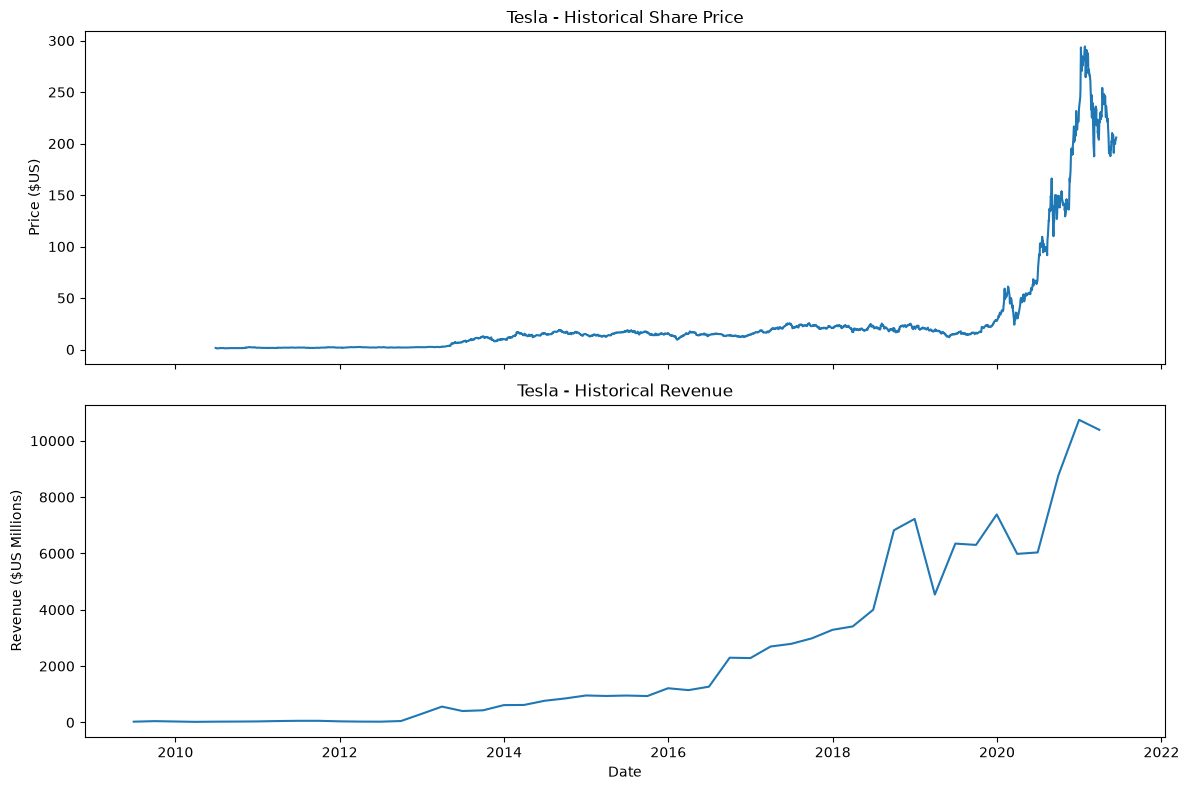

In [35]:

# Import libraries
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt


# Function to create graphs
def make_graph(stock_data, revenue_data, stock):

    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock Price Graph
    axes[0].plot(
        pd.to_datetime(stock_data_specific.Date),
        stock_data_specific.Close.astype("float")
    )

    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue Graph
    axes[1].plot(
        pd.to_datetime(revenue_data_specific.Date),
        revenue_data_specific.Revenue.astype("float")
    )

    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()


# ---------------- TESLA STOCK DATA ---------------- #

# Create Tesla ticker object
tesla = yf.Ticker("TSLA")

# Extract Tesla stock data
tesla_data = tesla.history(period="max")

# Reset index
tesla_data.reset_index(inplace=True)

# Display first 5 rows
print(tesla_data.head())


# ---------------- TESLA REVENUE DATA ---------------- #

# Download webpage
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

response = requests.get(url)

html_data = response.text

# Parse HTML
soup = BeautifulSoup(html_data, "html.parser")

# Create empty dataframe
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# Extract Tesla revenue table
tables = soup.find_all("table")

for table in tables:

    if "Tesla Quarterly Revenue" in str(table):

        for row in table.tbody.find_all("tr"):

            col = row.find_all("td")

            if len(col) != 0:

                date = col[0].text.strip()
                revenue = col[1].text.strip()

                tesla_revenue = pd.concat([
                    tesla_revenue,
                    pd.DataFrame({
                        "Date": [date],
                        "Revenue": [revenue]
                    })
                ], ignore_index=True)

# Clean Revenue column
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(",", "")
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace("$", "")

tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]

# Display first 5 rows
print(tesla_revenue.head())


# ---------------- GRAPH ---------------- #

# Plot Tesla graphs
make_graph(tesla_data, tesla_revenue, 'Tesla')

## GameStop Stock visualization


## GameStop Stock Price Visualization

The `make_graph` function is used to visualize GameStop's historical stock prices. The graph is limited to data available up to June 2021 to ensure consistency between stock price and revenue data.


                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620129  1.693350  1.603296  1.691667  76216000   
1 2002-02-14 00:00:00-05:00  1.712708  1.716074  1.670626  1.683251  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658002  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  
         Date Revenue
0  2020-04-30    1021
1  2020-01-31    2194
2  2019-10-31    1439
3  2019-07-31    1286
4  2019-04-30    1548


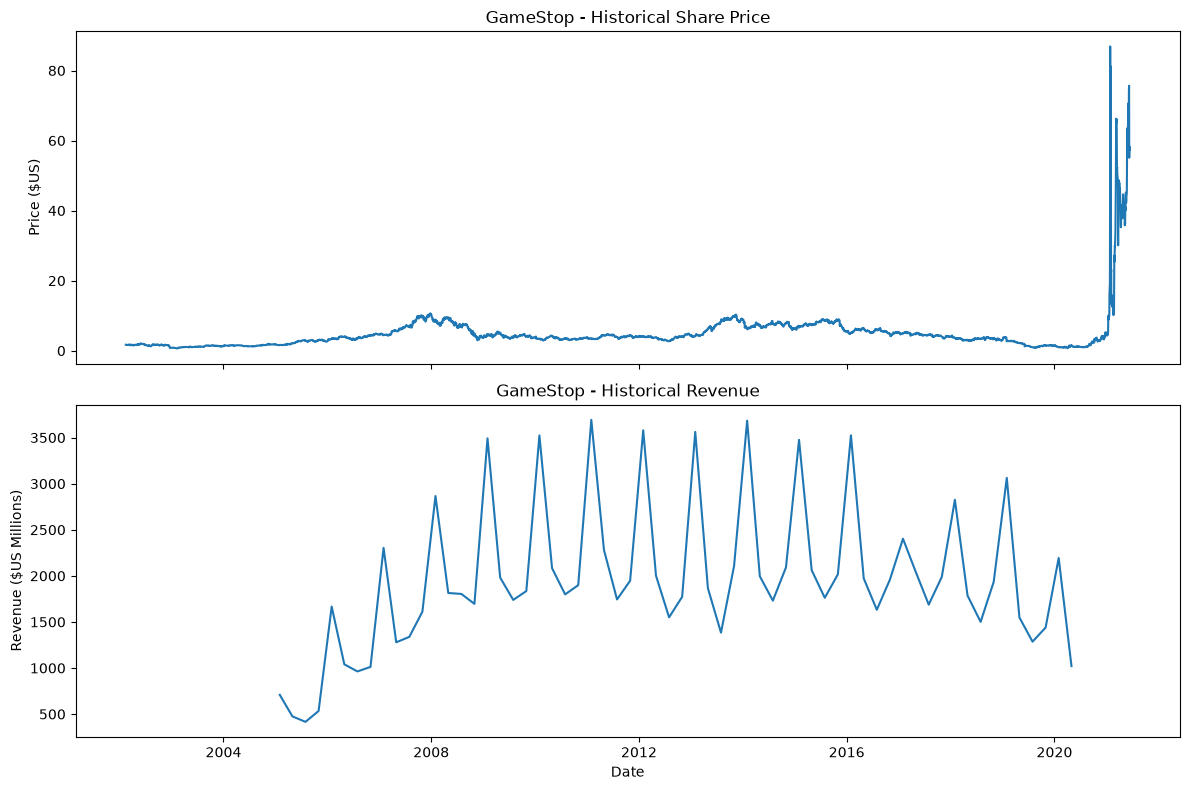

In [36]:
# Import libraries
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt


# ---------------- FUNCTION ---------------- #

def make_graph(stock_data, revenue_data, stock):

    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock Price Graph
    axes[0].plot(
        pd.to_datetime(stock_data_specific.Date),
        stock_data_specific.Close.astype("float")
    )

    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue Graph
    axes[1].plot(
        pd.to_datetime(revenue_data_specific.Date),
        revenue_data_specific.Revenue.astype("float")
    )

    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()


# ---------------- GAMESTOP STOCK DATA ---------------- #

# Create ticker object
gme = yf.Ticker("GME")

# Extract stock data
gme_data = gme.history(period="max")

# Reset index
gme_data.reset_index(inplace=True)

# Display first 5 rows
print(gme_data.head())


# ---------------- DOWNLOAD WEBPAGE ---------------- #

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

response = requests.get(url)

html_data_2 = response.text


# ---------------- PARSE HTML ---------------- #

soup_2 = BeautifulSoup(html_data_2, "html.parser")


# ---------------- CREATE EMPTY DATAFRAME ---------------- #

gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])


# ---------------- EXTRACT REVENUE TABLE ---------------- #

tables = soup_2.find_all("table")

for table in tables:

    if "GameStop Quarterly Revenue" in str(table):

        for row in table.tbody.find_all("tr"):

            col = row.find_all("td")

            if len(col) != 0:

                date = col[0].text.strip()
                revenue = col[1].text.strip()

                gme_revenue = pd.concat([
                    gme_revenue,
                    pd.DataFrame({
                        "Date": [date],
                        "Revenue": [revenue]
                    })
                ], ignore_index=True)


# ---------------- CLEAN REVENUE COLUMN ---------------- #

gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",", "")
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace("$", "")

gme_revenue.dropna(inplace=True)

gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]


# ---------------- DISPLAY DATAFRAME ---------------- #

print(gme_revenue.head())


# ---------------- GRAPH ---------------- #

make_graph(gme_data, gme_revenue, 'GameStop')

## Skills Demonstrated

#- API Integration using yfinance
#- Web Scraping with Requests and BeautifulSoup
#- Data Cleaning and Transformation
#- Exploratory Data Analysis (EDA)
#- Financial Data Analysis
#- Data Visualization using Plotly

#Conclusion

#This project successfully demonstrates the process of collecting, cleaning, and analyzing financial data from multiple sources. Historical stock prices were retrieved using the yfinance API, 
#while quarterly revenue data was extracted through web scraping techniques. After preprocessing the datasets,
#interactive visualizations were created to compare stock price movements with company revenue trends.

#The analysis highlights how combining data from different sources can provide meaningful insights into a company's financial performance. This project also showcases practical skills in API integration,
#web scraping, data manipulation, exploratory data analysis, and data visualization using Python, 
#making it a strong example of an end-to-end data analytics workflow.